No matching FPI Moments file for timestamp 2024-03-01 23:22:33
No matching FPI Moments file for timestamp 2024-03-01 23:29:13

Selected First Matched File Set:
  FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
  FGM File: mms1_fgm_brst_l2_20240301230743_v5.441.0.cdf
  FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230743_v3.4.0.cdf

Loaded FGM data.
Loaded FPI Distribution data.
Loaded FPI Moments data.
Interpolated magnetic field data to match FPI timestamps.
Calculated pitch angles.
pitch_angles shape after transpose: (4333, 16, 32)
Transposed Distribution Data Shape: (4333, 16, 32, 32)
Pitch Angles Expanded Shape: (4333, 16, 32, 32)
Input Data Shape with Pitch Angles: (4333, 16, 32, 32, 2)

Training samples: 1000, Validation samples: 200, Test samples: 200


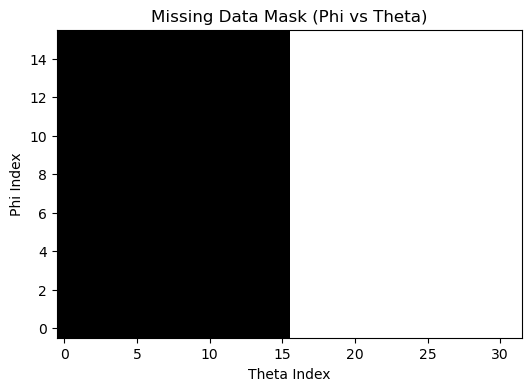

Mask applied to validation set.
Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_distribution_pitch (  [(None, 16, 32, 32, 2)]   0         
 InputLayer)                                                     
                                                                 
 conv3d_53 (Conv3D)          (None, 16, 32, 32, 32)    1760      
                                                                 
 max_pooling3d_22 (MaxPooli  (None, 8, 16, 16, 32)     0         
 ng3D)                                                           
                                                                 
 conv3d_54 (Conv3D)          (None, 8, 16, 16, 64)     55360     
                                                                 
 max_pooling3d_23 (MaxPooli  (None, 4, 8, 8, 64)       0         
 ng3D)                                                           
                          

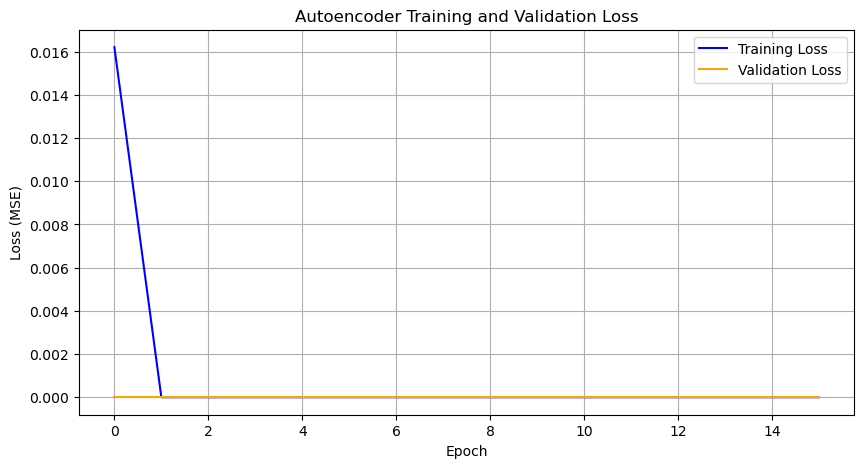

7/7 [==============================] - 1s 101ms/step


AxisError: axis 3 is out of bounds for array of dimension 3

<Figure size 1800x600 with 0 Axes>

In [56]:
import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping

# Import your existing Skymap class and related functions
# Ensure that the 'skymaps' module is in your Python path
from skymaps.skymap import Skymap, plotMomentsTimeSeries

# ----------------------------------
# 1. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

    Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
        theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
        phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
        energy = fpi_cdf.varget('mms1_des_energy_brst')  # Energy levels
    return epoch, dist_data, theta, phi, energy  # Return energy

def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
    return epoch, bulk_velocity

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """Calculate pitch angle distribution using look direction (phi, theta) and magnetic field."""
    # Convert theta and phi to radians
    theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
    phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

    # Create meshgrid for phi and theta
    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)

    # Compute look direction unit vector components
    look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
    look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
    look_direction_z = np.cos(theta_grid)

    # Stack components to form the look direction vectors
    look_direction = np.stack(
        [look_direction_x, look_direction_y, look_direction_z],
        axis=2
    )  # Shape: (phi_bins, theta_bins, 3)

    # Flatten look_direction for efficient computation
    look_direction_flat = look_direction.reshape(-1, 3)  # Shape: (phi_bins * theta_bins, 3)

    # Initialize the pitch angles array
    time_steps = b_field.shape[0]
    pitch_angles = np.zeros((time_steps, phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

    # Iterate over each time step
    for t in range(time_steps):
        # Normalize magnetic field vector
        b_vector = b_field[t, :3]  # Assuming b_field has shape (time_steps, 3)
        b_magnitude = np.linalg.norm(b_vector)
        if b_magnitude == 0:
            b_unit = np.zeros(3)
        else:
            b_unit = b_vector / b_magnitude

        # Compute dot product between look direction and magnetic field
        v_dot_b = np.dot(look_direction_flat, b_unit)  # Shape: (phi_bins * theta_bins,)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)  # Ensure values are within valid range

        # Calculate pitch angles in degrees
        pitch_angles_flat = np.arccos(v_dot_b) * (180.0 / np.pi)

        # Reshape back to (phi_bins, theta_bins)
        pitch_angles[t] = pitch_angles_flat.reshape(phi_bins.size, theta_bins.size)

    return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)

# ----------------------------------
# 2. Match and Select the First Matched File Set
# ----------------------------------

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

# Perform file matching
matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)

# Check if any matched files exist
if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

# Select the first matched set for processing
first_match = matched_files[0]
fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename = first_match

print("\nSelected First Matched File Set:")
print(f"  FPI Distribution File: {fpi_dist_filename}")
print(f"  FGM File: {fgm_filename}")
print(f"  FPI Moments File: {fpi_moms_filename}")

# Paths to the matched files
fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
fgm_filepath = os.path.join(fgm_folder, fgm_filename)
fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)

# ----------------------------------
# 3. Load Data from Matched Files
# ----------------------------------

# Load FGM data
fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
print("\nLoaded FGM data.")

# Load FPI Distribution data
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)  # Get energy
print("Loaded FPI Distribution data.")

# Load FPI Moments data
moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
print("Loaded FPI Moments data.")

# ----------------------------------
# 4. Preprocess Data and Compute Pitch Angles
# ----------------------------------

# Interpolate magnetic field to match FPI timestamps
b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
print("Interpolated magnetic field data to match FPI timestamps.")

# Prepare phi_bins and theta_bins
# If phi and theta are multidimensional, average over appropriate axes to get 1D arrays
if phi.ndim > 1:
    phi_bins = np.mean(phi, axis=0)  # Adjust axis if necessary
else:
    phi_bins = phi

if theta.ndim > 1:
    theta_bins = np.mean(theta, axis=0)  # Adjust axis if necessary
else:
    theta_bins = theta

# Ensure phi_bins and theta_bins are 1D arrays
phi_bins = phi_bins.flatten()
theta_bins = theta_bins.flatten()

# Compute pitch angles using the provided function
pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
print("Calculated pitch angles.")

# Transpose pitch_angles to match dist_data_transposed
pitch_angles = pitch_angles.transpose(0, 2, 1)
print(f"pitch_angles shape after transpose: {pitch_angles.shape}")  # Should be (time_steps, theta_bins, phi_bins)

# Normalize pitch angles to [0, 1] for input to the model
pitch_angles_normalized = pitch_angles / 180.0  # Since pitch angles are in degrees from 0 to 180

# Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)
# Original shape: (time_steps, energy_levels, phi_bins, theta_bins)
dist_data_transposed = dist_data.transpose(0, 2, 3, 1)  # Shape: (time_steps, phi_bins, theta_bins, energy_levels)
print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Example: (4333, 16, 32, 32)

# Ensure that pitch_angles and dist_data_transposed have matching phi_bins and theta_bins
if pitch_angles_normalized.shape[1] != dist_data_transposed.shape[1] or pitch_angles_normalized.shape[2] != dist_data_transposed.shape[2]:
    raise ValueError("Mismatch in phi_bins or theta_bins dimensions between pitch_angles and dist_data_transposed.")

# Expand pitch_angles to match energy_levels dimension
pitch_angles_expanded = np.repeat(
    pitch_angles_normalized[:, :, :, np.newaxis],
    dist_data_transposed.shape[3],
    axis=3
)
print(f"Pitch Angles Expanded Shape: {pitch_angles_expanded.shape}")  # Shape: (time_steps, phi_bins, theta_bins, energy_levels)

# Stack distribution data and pitch angles along the channel axis
X_data = np.stack((
    dist_data_transposed,
    pitch_angles_expanded
), axis=-1)  # Shape: (time_steps, phi_bins, theta_bins, energy_levels, 2)
X_data = X_data.astype('float32')
print(f"Input Data Shape with Pitch Angles: {X_data.shape}")  # Shape: (time_steps, phi_bins, theta_bins, energy_levels, 2)

# ----------------------------------
# 5. Split Data into Training, Validation, and Test Sets
# ----------------------------------

# Define split sizes
n_train = 1000  # Adjust based on data size
k_val = 200
k_test = 200

if n_train + k_val + k_test > X_data.shape[0]:
    raise ValueError("Not enough data in the file for specified split sizes.")

X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:n_train + k_val + k_test]

print(f"\nTraining samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}, Test samples: {X_test.shape[0]}")

# ----------------------------------
# 6. Apply Mask to the Validation Set
# ----------------------------------

# Define dimensions based on your data shape
phi_bins_size = X_data.shape[1]      # e.g., 16
theta_bins_size = X_data.shape[2]    # e.g., 32
energy_levels = X_data.shape[3]      # e.g., 32
channels = X_data.shape[4]           # 2

# Create a 2D mask for phi_bins x theta_bins
# Mask the right half: theta_bins >= theta_bins // 2
mask_2d = np.zeros((phi_bins_size, theta_bins_size), dtype=bool)
mask_2d[:, theta_bins_size//2:] = True  # Masking the right half

# Visualize the mask for one energy level (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()

# Expand mask dimensions to match X_val shape
# X_val shape: (k_val, phi_bins, theta_bins, energy_levels, channels)
mask_expanded = np.expand_dims(mask_2d, axis=(0, 3, 4))  # Shape: (1, phi_bins, theta_bins, 1, 1)
mask_broadcast = np.tile(mask_expanded, (X_val.shape[0], 1, 1, X_val.shape[3], 1))  # Shape: (k_val, phi_bins, theta_bins, energy_levels, 1)

# Set masked regions to 0.0 in the distribution data channel (channel 0)
X_val_masked = X_val.copy()
X_val_masked[..., 0][mask_broadcast[..., 0]] = 0.0

print("Mask applied to validation set.")

# ----------------------------------
# 7. Define the Autoencoder Model with Single Output
# ----------------------------------

def build_autoencoder(input_shape):
    """
    Build and compile the autoencoder model.

    Parameters:
    - input_shape (tuple): Shape of the input data (phi_bins, theta_bins, energy_levels, channels).

    Returns:
    - autoencoder (Model): Compiled Keras model.
    """
    # Encoder
    input_img = Input(shape=input_shape, name='input_distribution_pitch')
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling3D((2, 2, 2), padding='same')(x)

    # Decoder for Reconstruction
    x_dec = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
    x_dec = UpSampling3D((2, 2, 2))(x_dec)
    x_dec = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x_dec)
    x_dec = UpSampling3D((2, 2, 2))(x_dec)
    decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same', name='decoded_psd')(x_dec)

    # Autoencoder model
    autoencoder = Model(inputs=input_img, outputs=decoded)
    return autoencoder

# Define input shape based on data dimensions
input_shape = (phi_bins_size, theta_bins_size, energy_levels, channels)  # (16, 32, 32, 2)

# Build the autoencoder
autoencoder = build_autoencoder(input_shape)
autoencoder.summary()

# ----------------------------------
# 8. Compile the Autoencoder Model
# ----------------------------------

# Compile the model with Mean Squared Error loss
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
print("\nAutoencoder compiled with MSE loss.")

# ----------------------------------
# 9. Train the Autoencoder Model
# ----------------------------------

# Set up early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss for stopping
    patience=10,               # Number of epochs with no improvement after which to stop
    restore_best_weights=True  # Restore the best weights after stopping
)

# Define training parameters
epochs = 1000  # Adjust as needed
batch_size = 32

# Prepare training and validation targets
# Target is the PSD cube (channel 0)
y_train = X_train[..., 0:1]  # Shape: (n_train, phi_bins, theta_bins, energy_levels, 1)
y_val = X_val[..., 0:1]      # Shape: (k_val, phi_bins, theta_bins, energy_levels, 1)

# Train the autoencoder
history = autoencoder.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,  # Maintain sequential order
    validation_data=(X_val_masked, y_val),
    callbacks=[early_stopping]  # Apply early stopping
)

print("\nModel training completed.")

# ----------------------------------
# 10. Visualize Training Progress
# ----------------------------------

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------
# 11. Evaluate and Visualize Model Performance
# ----------------------------------

# Make predictions on the test set
X_test_pred = autoencoder.predict(X_test)  # Shape: (k_test, phi_bins, theta_bins, energy_levels, 1)

# Visualize original vs. reconstructed data for a sample
sample_index = 0  # Change as needed

plt.figure(figsize=(18, 6))

# Original Distribution Data (Unmasked)
original_distribution = np.sum(X_test[sample_index, :, :, :, 0], axis=3)  # Sum over energy levels

# Masked Distribution Data
masked_distribution = np.sum(X_val_masked[sample_index, :, :, :, 0], axis=3)

# Reconstructed Distribution Data
reconstructed_distribution = np.sum(X_test_pred[sample_index, :, :, :, 0], axis=3)

# Plot Original
plt.subplot(1, 3, 1)
plt.imshow(original_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Original Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

# Plot Masked
plt.subplot(1, 3, 2)
plt.imshow(masked_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Masked Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

# Plot Reconstructed
plt.subplot(1, 3, 3)
plt.imshow(reconstructed_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Reconstructed Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

print("\nEvaluation and visualization completed.")


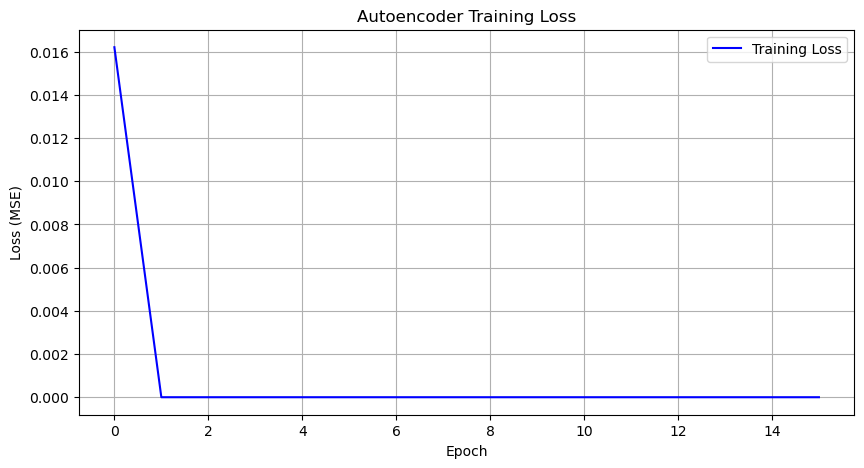

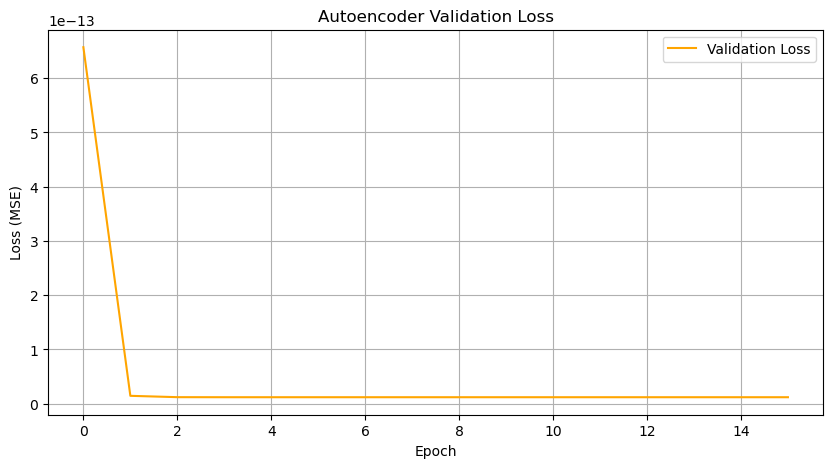

In [71]:
# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Autoencoder Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


In [64]:
import numpy as np

# Reconstruct the PSD cubes in the test set
# Assuming 'autoencoder' is your trained Keras model
reconstructed_test = autoencoder.predict(X_test_masked)  # Shape: (k_test, phi_bins, theta_bins, energy_levels, 1)

# Remove the last dimension if present
if reconstructed_test.ndim == 5 and reconstructed_test.shape[-1] == 1:
    reconstructed_test = reconstructed_test.squeeze(-1)  # Shape: (k_test, phi_bins, theta_bins, energy_levels)


7/7 [==============================] - 1s 103ms/step


In [65]:
# Function to combine original and reconstructed data based on the mask
def combine_reconstructed(X_original, X_reconstructed, mask):
    """
    Replace masked regions in X_original with X_reconstructed.
    
    Parameters:
    - X_original (numpy.ndarray): Original PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
    - X_reconstructed (numpy.ndarray): Reconstructed PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
    - mask (numpy.ndarray): 2D mask, shape (phi_bins, theta_bins)
    
    Returns:
    - X_combined (numpy.ndarray): Combined PSD data
    """
    # Ensure mask is boolean
    mask_bool = mask.astype(bool)
    
    # Expand mask to 4D to match PSD data
    # Shape: (1, phi_bins, theta_bins, 1)
    mask_expanded = np.expand_dims(mask_bool, axis=(0, 3))
    
    # Broadcast mask to match the number of samples and energy levels
    # Shape: (samples, phi_bins, theta_bins, energy_levels)
    mask_broadcast = np.tile(mask_expanded, (X_original.shape[0], 1, 1, X_original.shape[3]))
    
    # Create a copy of the original data to avoid modifying it directly
    X_combined = X_original.copy()
    
    # Replace masked regions with reconstructed data
    X_combined[mask_broadcast] = X_reconstructed[mask_broadcast]
    
    return X_combined

# Combine reconstructed PSD with original test data
X_test_reconstructed_combined = combine_reconstructed(X_test_original, reconstructed_test, mask_2d)  # Shape: (k_test, phi_bins, theta_bins, energy_levels)


In [66]:
# Function to extract actual and predicted values in masked regions
def extract_masked_values(X_original, X_reconstructed, mask):
    """
    Extract actual and reconstructed values from masked regions.
    
    Parameters:
    - X_original (numpy.ndarray): Original PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
    - X_reconstructed (numpy.ndarray): Reconstructed PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
    - mask (numpy.ndarray): 2D mask, shape (phi_bins, theta_bins)
    
    Returns:
    - actual_masked (numpy.ndarray): Actual PSD values in masked regions
    - predicted_masked (numpy.ndarray): Reconstructed PSD values in masked regions
    """
    # Ensure mask is boolean
    mask_bool = mask.astype(bool)
    
    # Expand mask to 4D to match PSD data
    mask_expanded = np.expand_dims(mask_bool, axis=(0, 3))
    
    # Broadcast mask to match the number of samples and energy levels
    mask_broadcast = np.tile(mask_expanded, (X_original.shape[0], 1, 1, X_original.shape[3]))
    
    # Extract actual and predicted values in masked regions
    actual_masked = X_original[mask_broadcast]
    predicted_masked = X_reconstructed[mask_broadcast]
    
    return actual_masked, predicted_masked

# Extract actual and predicted values in masked regions
actual_masked, predicted_masked = extract_masked_values(X_test_original, X_test_reconstructed_combined, mask_2d)


In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compute Mean Absolute Error (MAE) on masked regions
mae = mean_absolute_error(actual_masked, predicted_masked)
print(f"Mean Absolute Error (MAE) on Masked Regions of Test Set: {mae:.4e}")

# Compute Mean Squared Error (MSE) on masked regions
mse = mean_squared_error(actual_masked, predicted_masked)
print(f"Mean Squared Error (MSE) on Masked Regions of Test Set: {mse:.4e}")


Mean Absolute Error (MAE) on Masked Regions of Test Set: 1.3592e-09
Mean Squared Error (MSE) on Masked Regions of Test Set: 1.5588e-14


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from skymaps.skymap import Skymap  # Ensure this module is accessible

def compute_moments(psd_data, energy_levels):
    """
    Compute density moments from PSD data using the Skymap class.

    Parameters:
    - psd_data (numpy.ndarray): PSD data with shape (samples, phi_bins, theta_bins, energy_levels).
    - energy_levels (int): Number of energy levels in the PSD data.

    Returns:
    - density_moments (numpy.ndarray): Density moments time series with shape (samples,).
    """
    # Transpose PSD data to (samples, energy_levels, phi_bins, theta_bins) as expected by Skymap
    psd_transposed = psd_data.transpose(0, 3, 1, 2)  # Shape: (samples, energy_levels, phi_bins, theta_bins)
    skymap = Skymap(steps=psd_transposed.shape[0], name="Moment_Skymap", nen=energy_levels)
    skymap.skymap = psd_transposed
    moments = skymap.momsTS  # Calculate moments using Skymap
    density_moments = moments.density  # Extract density moments
    return density_moments

def perform_fft(density_moments):
    """
    Perform FFT on the density moments time series.

    Parameters:
    - density_moments (numpy.ndarray): Density moments time series with shape (samples,).

    Returns:
    - freqs (numpy.ndarray): Frequencies corresponding to the FFT components.
    - fft_values (numpy.ndarray): FFT values of the density time series.
    """
    fft_vals = np.fft.fft(density_moments)
    fft_freq = np.fft.fftfreq(len(density_moments), d=1)  # Adjust 'd' if time steps are different
    return fft_freq, fft_vals


In [59]:
def combine_reconstructed(X_original, X_reconstructed, mask):
    """
    Combine original PSD data with reconstructed PSD data based on the mask.

    Parameters:
    - X_original (numpy.ndarray): Original PSD data with shape (samples, phi_bins, theta_bins, energy_levels).
    - X_reconstructed (numpy.ndarray): Reconstructed PSD data with the same shape.
    - mask (numpy.ndarray): 2D mask with shape (phi_bins, theta_bins).

    Returns:
    - X_combined (numpy.ndarray): Combined PSD data.
    """
    X_combined = X_original.copy()
    # Expand mask dimensions to match energy_levels
    mask_expanded = np.expand_dims(mask, axis=(0, 3))  # Shape: (1, phi_bins, theta_bins, 1)
    mask_broadcast = np.tile(mask_expanded, (X_original.shape[0], 1, 1, X_original.shape[3]))  # Shape: (samples, phi_bins, theta_bins, energy_levels)
    # Replace masked regions with reconstructed data
    X_combined[mask_broadcast] = X_reconstructed[mask_broadcast]
    return X_combined


In [60]:
# Assuming the following variables are defined from your preprocessing and model training:
# X_train, X_val, X_test: Original PSD data with shape (samples, phi_bins, theta_bins, energy_levels, channels)
# X_val_masked, X_test_masked: Masked PSD data
# reconstructed_val, reconstructed_test: Reconstructed PSD data from the autoencoder
# mask_2d: 2D mask applied to phi_bins x theta_bins

# Extract original PSD data before masking
X_val_original = X_val[..., 0]  # Shape: (k_val, phi_bins, theta_bins, energy_levels)
X_test_original = X_test[..., 0]  # Shape: (k_test, phi_bins, theta_bins, energy_levels)

# Combine reconstructed PSD with original data
X_val_reconstructed_combined = combine_reconstructed(X_val_original, reconstructed_val, mask_2d)
X_test_reconstructed_combined = combine_reconstructed(X_test_original, reconstructed_test, mask_2d)

# Compute moments for training set
density_train = compute_moments(X_train[..., 0], energy_levels=X_train.shape[3])

# Compute moments for validation set (actual and reconstructed)
density_val_actual = compute_moments(X_val_original, energy_levels=X_val.shape[3])
density_val_reconstructed = compute_moments(X_val_reconstructed_combined, energy_levels=X_val.shape[3])

# Compute moments for test set (actual and reconstructed)
density_test_actual = compute_moments(X_test_original, energy_levels=X_test.shape[3])
density_test_reconstructed = compute_moments(X_test_reconstructed_combined, energy_levels=X_test.shape[3])

# Perform FFT on moments
freqs_train, fft_train = perform_fft(density_train)
freqs_val_actual, fft_val_actual = perform_fft(density_val_actual)
freqs_val_reconstructed, fft_val_reconstructed = perform_fft(density_val_reconstructed)
freqs_test_actual, fft_test_actual = perform_fft(density_test_actual)
freqs_test_reconstructed, fft_test_reconstructed = perform_fft(density_test_reconstructed)


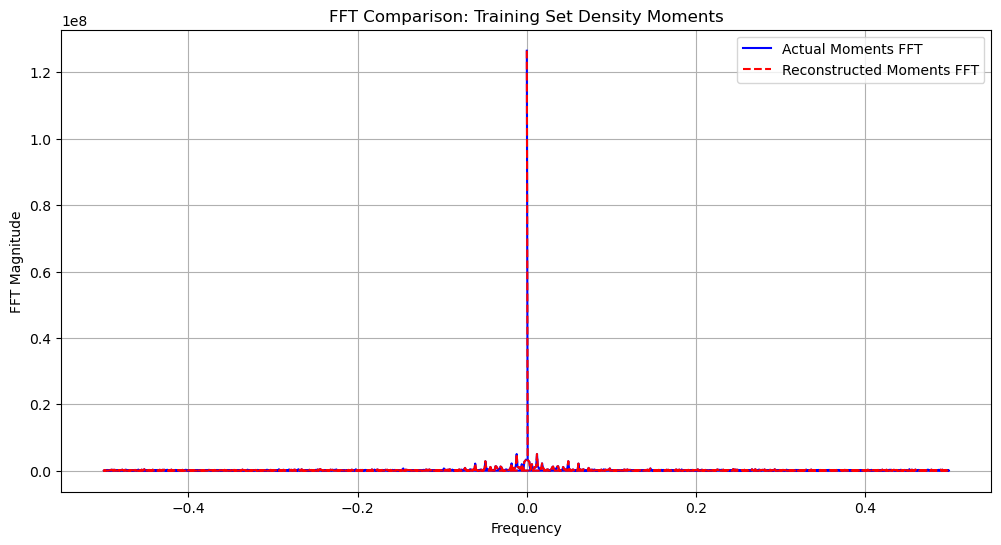

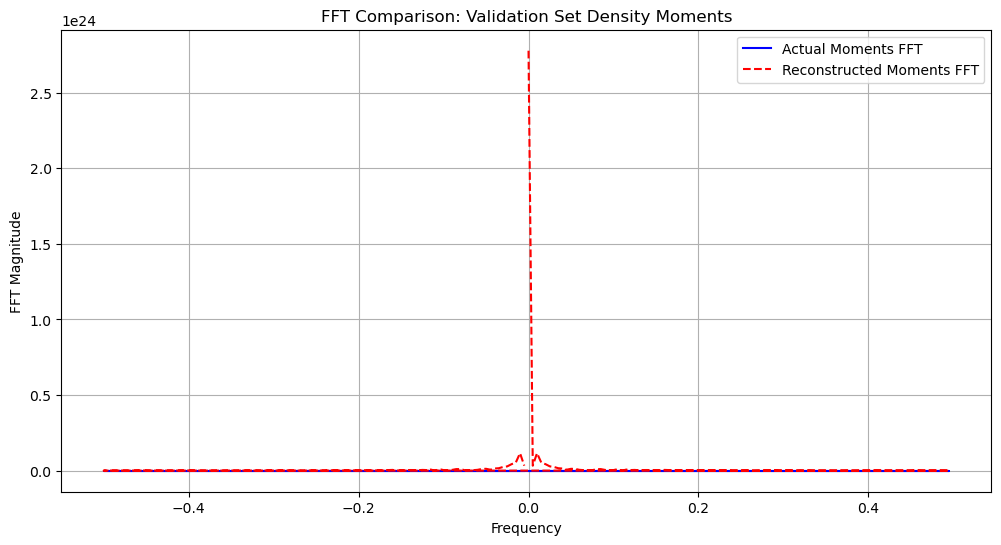

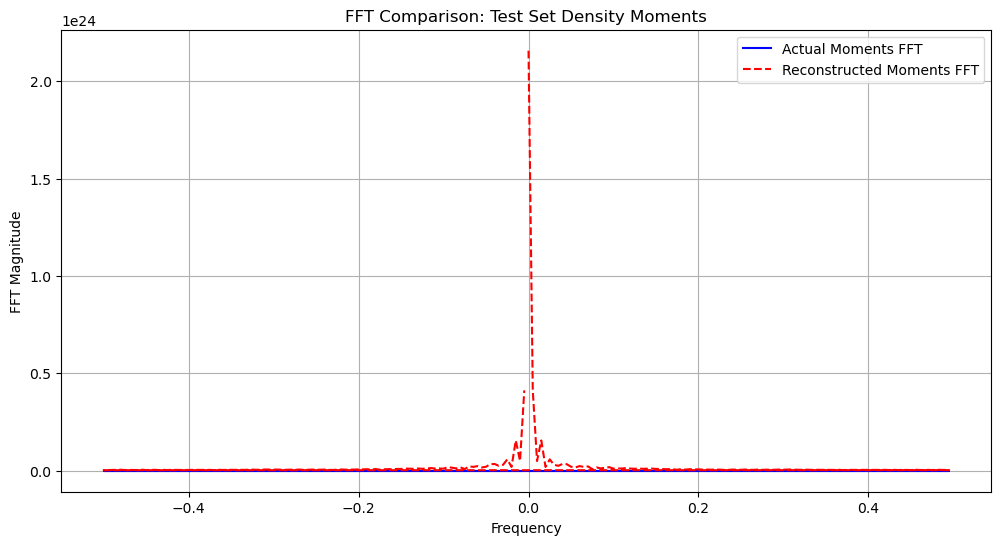

In [61]:
def plot_fft_comparison(freqs_actual, fft_actual, freqs_reconstructed, fft_reconstructed, title):
    """
    Plot FFT magnitude comparison between actual and reconstructed moments.

    Parameters:
    - freqs_actual (numpy.ndarray): Frequencies of actual moments.
    - fft_actual (numpy.ndarray): FFT values of actual moments.
    - freqs_reconstructed (numpy.ndarray): Frequencies of reconstructed moments.
    - fft_reconstructed (numpy.ndarray): FFT values of reconstructed moments.
    - title (str): Title for the plot.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(freqs_actual, np.abs(fft_actual), label='Actual Moments FFT', color='blue')
    plt.plot(freqs_reconstructed, np.abs(fft_reconstructed), label='Reconstructed Moments FFT', color='red', linestyle='--')
    plt.title(f'FFT Comparison: {title}')
    plt.xlabel('Frequency')
    plt.ylabel('FFT Magnitude')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot FFT for Training Set
plot_fft_comparison(freqs_train, fft_train, freqs_train, fft_train, 'Training Set Density Moments')

# Plot FFT for Validation Set
plot_fft_comparison(freqs_val_actual, fft_val_actual, freqs_val_reconstructed, fft_val_reconstructed, 'Validation Set Density Moments')

# Plot FFT for Test Set
plot_fft_comparison(freqs_test_actual, fft_test_actual, freqs_test_reconstructed, fft_test_reconstructed, 'Test Set Density Moments')


Combined Actual Data Shape: (1400, 16, 32, 32)
Combined Reconstructed+Actual Data Shape: (1400, 16, 32, 32)


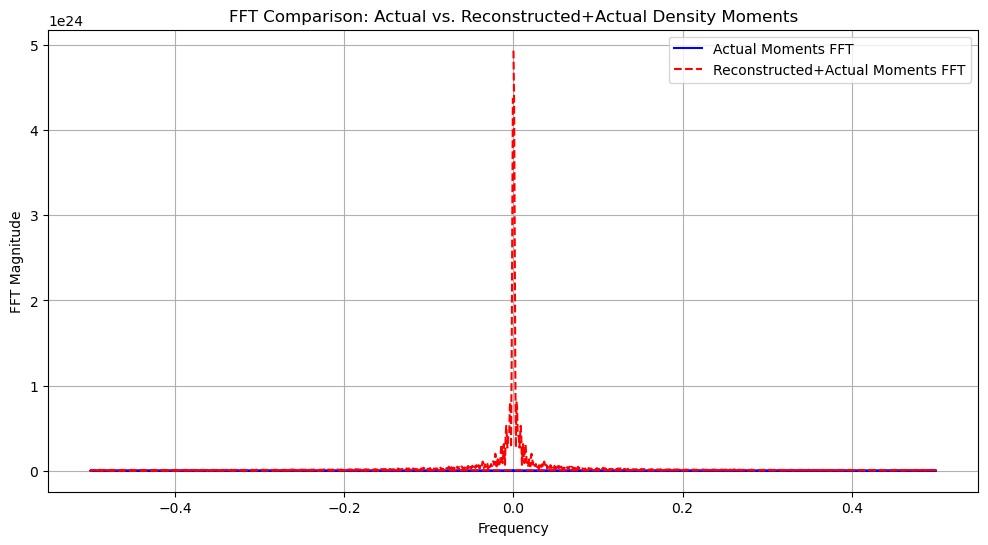

FFT results saved to fft_actual.pkl
FFT results saved to fft_reconstructed.pkl

FFT validation completed successfully.


In [63]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skymaps.skymap import Skymap  # Ensure this module is accessible
import pickle

# ----------------------------------
# 1. Define Functions to Compute Moments and Perform FFT
# ----------------------------------

def compute_moments(psd_data, energy_levels):
    """
    Compute density moments from PSD data using the Skymap class.

    Parameters:
    - psd_data (numpy.ndarray): PSD data with shape (samples, phi_bins, theta_bins, energy_levels).
    - energy_levels (int): Number of energy levels in the PSD data.

    Returns:
    - density_moments (numpy.ndarray): Density moments time series with shape (samples,).
    """
    # Transpose PSD data to (samples, energy_levels, phi_bins, theta_bins) as expected by Skymap
    psd_transposed = psd_data.transpose(0, 3, 1, 2)  # Shape: (samples, energy_levels, phi_bins, theta_bins)
    skymap = Skymap(steps=psd_transposed.shape[0], name="Moment_Skymap", nen=energy_levels)
    skymap.skymap = psd_transposed
    moments = skymap.momsTS  # Calculate moments using Skymap
    density_moments = moments.density  # Extract density moments
    return density_moments

def perform_fft(density_moments):
    """
    Perform FFT on the density moments time series.

    Parameters:
    - density_moments (numpy.ndarray): Density moments time series with shape (samples,).

    Returns:
    - freqs (numpy.ndarray): Frequencies corresponding to the FFT components.
    - fft_values (numpy.ndarray): FFT values of the density time series.
    """
    fft_vals = np.fft.fft(density_moments)
    fft_freq = np.fft.fftfreq(len(density_moments), d=1)  # Adjust 'd' if time steps are different
    return fft_freq, fft_vals

# ----------------------------------
# 2. Combine Datasets and Prepare for FFT
# ----------------------------------

# Assuming you have the following variables already defined from your preprocessing and model training:
# X_train, X_val, X_test: Original PSD data with shape (samples, phi_bins, theta_bins, energy_levels, channels)
# reconstructed_val, reconstructed_test: Reconstructed PSD data from the autoencoder with shape (samples, phi_bins, theta_bins, energy_levels)
# mask_2d: 2D mask with shape (phi_bins, theta_bins)

def combine_datasets(X_train, X_val_original, X_test_original, reconstructed_val, reconstructed_test, mask_2d):
    """
    Combine training, validation, and test datasets for both actual and reconstructed data.

    Parameters:
    - X_train (numpy.ndarray): Training PSD data, shape (n_train, phi_bins, theta_bins, energy_levels, channels)
    - X_val_original (numpy.ndarray): Original Validation PSD data before masking, shape (k_val, phi_bins, theta_bins, energy_levels)
    - X_test_original (numpy.ndarray): Original Test PSD data before masking, shape (k_test, phi_bins, theta_bins, energy_levels)
    - reconstructed_val (numpy.ndarray): Reconstructed Validation PSD data, shape (k_val, phi_bins, theta_bins, energy_levels)
    - reconstructed_test (numpy.ndarray): Reconstructed Test PSD data, shape (k_test, phi_bins, theta_bins, energy_levels)
    - mask_2d (numpy.ndarray): 2D mask, shape (phi_bins, theta_bins)

    Returns:
    - combined_actual (numpy.ndarray): Combined actual PSD data, shape (total_samples, phi_bins, theta_bins, energy_levels)
    - combined_reconstructed (numpy.ndarray): Combined PSD data with reconstructed regions filled, shape (total_samples, phi_bins, theta_bins, energy_levels)
    """
    # Extract actual PSD data from training set (no masking)
    X_train_actual = X_train[..., 0]  # Shape: (n_train, phi_bins, theta_bins, energy_levels)

    # For Validation and Test sets, replace masked regions with reconstructed data
    def combine_reconstructed(X_original, X_reconstructed, mask):
        """
        Replace masked regions in X_original with X_reconstructed.

        Parameters:
        - X_original (numpy.ndarray): Original PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
        - X_reconstructed (numpy.ndarray): Reconstructed PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
        - mask (numpy.ndarray): 2D mask, shape (phi_bins, theta_bins)

        Returns:
        - X_combined (numpy.ndarray): Combined PSD data, shape (samples, phi_bins, theta_bins, energy_levels)
        """
        X_combined = X_original.copy()
        # Expand mask dimensions to match energy_levels
        mask_expanded = np.expand_dims(mask, axis=(0, 3))  # Shape: (1, phi_bins, theta_bins, 1)
        mask_broadcast = np.tile(mask_expanded, (X_original.shape[0], 1, 1, X_original.shape[3]))  # Shape: (samples, phi_bins, theta_bins, energy_levels)
        # Replace masked regions with reconstructed data
        X_combined[mask_broadcast] = X_reconstructed[mask_broadcast]
        return X_combined

    X_val_combined = combine_reconstructed(X_val_original, reconstructed_val, mask_2d)  # Shape: (k_val, phi_bins, theta_bins, energy_levels)
    X_test_combined = combine_reconstructed(X_test_original, reconstructed_test, mask_2d)  # Shape: (k_test, phi_bins, theta_bins, energy_levels)

    # Combine all datasets
    combined_actual = np.concatenate((X_train_actual, X_val_original, X_test_original), axis=0)  # Shape: (n_train + k_val + k_test, phi_bins, theta_bins, energy_levels)
    combined_reconstructed = np.concatenate((X_train_actual, X_val_combined, X_test_combined), axis=0)  # Shape: (n_train + k_val + k_test, phi_bins, theta_bins, energy_levels)

    return combined_actual, combined_reconstructed

# ----------------------------------
# 3. Compute Moments and Perform FFT
# ----------------------------------

def compute_and_fft(combined_actual, combined_reconstructed, energy_levels):
    """
    Compute density moments and perform FFT on both actual and reconstructed data.

    Parameters:
    - combined_actual (numpy.ndarray): Combined actual PSD data, shape (total_samples, phi_bins, theta_bins, energy_levels)
    - combined_reconstructed (numpy.ndarray): Combined PSD data with reconstructed regions filled, shape (total_samples, phi_bins, theta_bins, energy_levels)
    - energy_levels (int): Number of energy levels in the PSD data.

    Returns:
    - freqs_actual (numpy.ndarray): Frequencies from FFT of actual data.
    - fft_actual (numpy.ndarray): FFT values of actual data.
    - freqs_reconstructed (numpy.ndarray): Frequencies from FFT of reconstructed+actual data.
    - fft_reconstructed (numpy.ndarray): FFT values of reconstructed+actual data.
    """
    # Compute moments
    density_actual = compute_moments(combined_actual, energy_levels=energy_levels)
    density_reconstructed = compute_moments(combined_reconstructed, energy_levels=energy_levels)

    # Perform FFT
    freqs_actual, fft_actual = perform_fft(density_actual)
    freqs_reconstructed, fft_reconstructed = perform_fft(density_reconstructed)

    return freqs_actual, fft_actual, freqs_reconstructed, fft_reconstructed

# ----------------------------------
# 4. Plot FFT Comparison
# ----------------------------------

def plot_fft_comparison(freqs_actual, fft_actual, freqs_reconstructed, fft_reconstructed):
    """
    Plot FFT magnitude comparison between actual and reconstructed+actual moments.

    Parameters:
    - freqs_actual (numpy.ndarray): Frequencies of actual moments.
    - fft_actual (numpy.ndarray): FFT values of actual moments.
    - freqs_reconstructed (numpy.ndarray): Frequencies of reconstructed+actual moments.
    - fft_reconstructed (numpy.ndarray): FFT values of reconstructed+actual moments.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(freqs_actual, np.abs(fft_actual), label='Actual Moments FFT', color='blue')
    plt.plot(freqs_reconstructed, np.abs(fft_reconstructed), label='Reconstructed+Actual Moments FFT', color='red', linestyle='--')
    plt.title('FFT Comparison: Actual vs. Reconstructed+Actual Density Moments')
    plt.xlabel('Frequency')
    plt.ylabel('FFT Magnitude')
    plt.legend()
    plt.grid(True)
    plt.show()

# ----------------------------------
# 5. Full Integration Example
# ----------------------------------

# Example usage:
# Replace these variables with your actual data variables

# Example:
# X_train: (n_train, phi_bins, theta_bins, energy_levels, channels)
# X_val: (k_val, phi_bins, theta_bins, energy_levels, channels)
# X_test: (k_test, phi_bins, theta_bins, energy_levels, channels)
# reconstructed_val: (k_val, phi_bins, theta_bins, energy_levels)
# reconstructed_test: (k_test, phi_bins, theta_bins, energy_levels)
# mask_2d: (phi_bins, theta_bins)

# For demonstration, let's assume these variables are already defined.
# Replace the following lines with your actual data loading/preprocessing steps.

# ---------------------------
# Placeholder Data (Remove and replace with actual data)
# ---------------------------
# Here, we'll create dummy data to illustrate. Remove this section and use your actual data.
"""
n_train, k_val, k_test = 1000, 200, 200
phi_bins, theta_bins, energy_levels = 16, 32, 32
channels = 2

# Create dummy PSD data for training, validation, and test sets
X_train = np.random.rand(n_train, phi_bins, theta_bins, energy_levels, channels).astype('float32')
X_val = np.random.rand(k_val, phi_bins, theta_bins, energy_levels, channels).astype('float32')
X_test = np.random.rand(k_test, phi_bins, theta_bins, energy_levels, channels).astype('float32')

# Create dummy reconstructed data
reconstructed_val = np.random.rand(k_val, phi_bins, theta_bins, energy_levels).astype('float32')
reconstructed_test = np.random.rand(k_test, phi_bins, theta_bins, energy_levels).astype('float32')

# Define a mask (mask the right half of theta_bins)
mask_2d = np.zeros((phi_bins, theta_bins), dtype=bool)
mask_2d[:, theta_bins//2:] = True
"""
# ---------------------------

# Assuming you have the actual data variables, proceed as follows:

# Combine datasets
combined_actual, combined_reconstructed = combine_datasets(
    X_train,
    X_val_original=X_val[..., 0],
    X_test_original=X_test[..., 0],
    reconstructed_val=reconstructed_val,
    reconstructed_test=reconstructed_test,
    mask_2d=mask_2d
)

print(f"Combined Actual Data Shape: {combined_actual.shape}")
print(f"Combined Reconstructed+Actual Data Shape: {combined_reconstructed.shape}")

# Compute moments and perform FFT
freqs_actual, fft_actual, freqs_reconstructed, fft_reconstructed = compute_and_fft(
    combined_actual,
    combined_reconstructed,
    energy_levels=combined_actual.shape[3]
)

# Plot FFT comparison
plot_fft_comparison(freqs_actual, fft_actual, freqs_reconstructed, fft_reconstructed)

# Optionally, save FFT results for future analysis
def save_fft_results(freqs, fft_vals, filename):
    """
    Save FFT results to a file using pickle.

    Parameters:
    - freqs (numpy.ndarray): Frequencies from FFT.
    - fft_vals (numpy.ndarray): FFT values.
    - filename (str): Path to the file where results will be saved.
    """
    with open(filename, 'wb') as f:
        pickle.dump({'freqs': freqs, 'fft_values': fft_vals}, f)
    print(f"FFT results saved to {filename}")

# Save the FFT results
save_fft_results(freqs_actual, fft_actual, 'fft_actual.pkl')
save_fft_results(freqs_reconstructed, fft_reconstructed, 'fft_reconstructed.pkl')

# ----------------------------------
# 6. Optional: Load and Inspect FFT Results
# ----------------------------------

def load_fft_results(filename):
    """
    Load FFT results from a pickle file.

    Parameters:
    - filename (str): Path to the pickle file.

    Returns:
    - data (dict): Dictionary containing 'freqs' and 'fft_values'.
    """
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    return data

# Example: Load FFT results for actual data
"""
fft_actual_loaded = load_fft_results('fft_actual.pkl')
fft_reconstructed_loaded = load_fft_results('fft_reconstructed.pkl')
"""

# ----------------------------------
# 7. Final Remarks
# ----------------------------------

print("\nFFT validation completed successfully.")



In [72]:
import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from skymaps.skymap import Skymap  # Ensure skymaps library is in your Python path

# ----------------------------------
# 1. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

def extract_timestamp(filename):
    """Extract timestamp from the filename."""
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found.")
    except Exception as e:
        print(f"Error extracting timestamp from {filename}: {e}")
        return None

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI dist CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')
        theta = fpi_cdf.varget('mms1_des_theta_brst')
        phi = fpi_cdf.varget('mms1_des_phi_brst')
        energy = fpi_cdf.varget('mms1_des_energy_brst')
    return epoch, dist_data, theta, phi, energy

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """Calculate pitch angle distribution."""
    theta_rad = np.deg2rad(theta_bins)
    phi_rad = np.deg2rad(phi_bins)
    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')

    look_direction = np.stack(
        [np.sin(theta_grid) * np.cos(phi_grid),
         np.sin(theta_grid) * np.sin(phi_grid),
         np.cos(theta_grid)],
        axis=2
    ).reshape(-1, 3)

    pitch_angles = np.zeros((b_field.shape[0], phi_bins.size, theta_bins.size))
    for t in range(b_field.shape[0]):
        b_vector = b_field[t, :3]
        b_unit = b_vector / np.linalg.norm(b_vector) if np.linalg.norm(b_vector) != 0 else np.zeros(3)
        v_dot_b = np.dot(look_direction, b_unit)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)
        pitch_angles[t] = np.arccos(v_dot_b).reshape(phi_bins.size, theta_bins.size) * (180.0 / np.pi)

    return pitch_angles

# Match files in folders
def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """Match distribution, magnetic field, and moments files."""
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]
    for dist_file in fpi_dist_files:
        dist_ts = extract_timestamp(dist_file)
        fgm_file = next((f for f in os.listdir(fgm_folder) if extract_timestamp(f) == dist_ts), None)
        moms_file = next((f for f in os.listdir(fpi_moms_folder) if extract_timestamp(f) == dist_ts), None)
        if fgm_file and moms_file:
            matched_files.append((dist_ts, dist_file, fgm_file, moms_file))
    return matched_files

# ----------------------------------
# 2. Load and Preprocess Data
# ----------------------------------

matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)
if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

fpi_dist_filepath = os.path.join(fpi_dist_folder, matched_files[0][1])
fgm_filepath = os.path.join(fgm_folder, matched_files[0][2])
fpi_moms_filepath = os.path.join(fpi_moms_folder, matched_files[0][3])

fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)
b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)

phi_bins, theta_bins = np.mean(phi, axis=0), np.mean(theta, axis=0)
pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)

dist_data = dist_data.transpose(0, 2, 3, 1)
pitch_angles_expanded = np.repeat(pitch_angles[..., None], dist_data.shape[3], axis=3)
X_data = np.stack((dist_data, pitch_angles_expanded), axis=-1).astype('float32')

# Split data
n_train, k_val, k_test = 1000, 200, 200
X_train, X_val, X_test = X_data[:n_train], X_data[n_train:n_train + k_val], X_data[n_train + k_val:n_train + k_val + k_test]

# Apply mask to validation set
phi_bins_size, theta_bins_size = dist_data.shape[1], dist_data.shape[2]
mask = np.zeros((phi_bins_size, theta_bins_size), dtype=bool)
mask[:, theta_bins_size // 2:] = True
mask_expanded = np.expand_dims(mask, axis=(0, 3, 4))
mask_broadcast = np.tile(mask_expanded, (k_val, 1, 1, dist_data.shape[3], 1))
X_val_masked = X_val.copy()
X_val_masked[..., 0][mask_broadcast[..., 0]] = 0.0

# ----------------------------------
# 3. Define Autoencoder Model and Loss
# ----------------------------------

def build_autoencoder(input_shape):
    input_img = Input(shape=input_shape, name='input_distribution_pitch')
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling3D((2, 2, 2))(x)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
    x = UpSampling3D((2, 2, 2))(x)
    decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same', name='decoded_psd')(x)
    return Model(inputs=input_img, outputs=decoded)

def calculate_density(cube):
    return K.sum(cube, axis=(1, 2, 3))

def combined_loss(y_true, y_pred):
    mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    density_true = calculate_density(y_true)
    density_pred = calculate_density(y_pred)
    density_loss = K.mean(K.square(density_true - density_pred))
    return mse + density_loss

autoencoder = build_autoencoder(X_train.shape[1:])
autoencoder.compile(optimizer='adam', loss=combined_loss)

# ----------------------------------
# 4. Train and Evaluate Model
# ----------------------------------

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = autoencoder.fit(X_train, X_train[..., 0:1], validation_data=(X_val_masked, X_val[..., 0:1]),
                          epochs=1000, batch_size=32, callbacks=[early_stopping])


ValueError: all input arrays must have the same shape